In [301]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import mlflow
import matplotlib.pyplot as plt

%matplotlib widget

In [302]:
RUN_ID = 'dd9db1fd7e684aa2911d4d5831625f97'

In [303]:
# load mode parameter from data
lure_params_path = 'lure_model_params_scaled.npz'
theta = np.load(lure_params_path)
# print(f'Saved Lur\'e model parameters to {lure_params_path}')
A_fit = theta['A']
B_fit = theta['B']
C_fit = theta['C']
B2_fit = theta['B2']
C2_fit = theta['C2']
D_fit = theta['D']
D12_fit = theta['D12']
D21_fit = theta['D21']
TS = float(theta['TS'])
nz = int(theta['nz'])
nx = int(theta['nx'])
nd = int(theta['nu'])
ne = int(theta['ny'])

In [304]:
# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from sysid.data import DataNormalizer
from sysid.models import SimpleLure

# Set MLflow tracking URI (adjust if needed)
mlflow_uri = project_root / "mlruns"
mlflow.set_tracking_uri(f"file://{mlflow_uri}")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

# Load model architecture from MLflow (logged at end of training as 'final' model)
print(f"Loading model from run {RUN_ID}...")
model_uri = f"runs:/{RUN_ID}/model"
model = mlflow.pytorch.load_model(model_uri)
print(f"Model loaded: {type(model).__name__}")
print(f"Model parameters: {model.count_parameters():,}")

# Load best model weights (saved whenever validation loss improved during training)
# This overwrites the final model weights with the best checkpoint weights
print("Loading best model weights from checkpoint artifact...")
try:
    best_model_path = mlflow.artifacts.download_artifacts(
        run_id=RUN_ID, artifact_path="models/best_model.pt"
    )
    checkpoint = torch.load(best_model_path, map_location="cpu")
    model.load_state_dict(checkpoint["model_state_dict"])
    best_epoch = checkpoint.get("best_epoch", "?")
    best_val_loss = checkpoint.get("best_val_loss", "?")
    print(f"Best model weights loaded (best epoch: {best_epoch}, best val loss: {best_val_loss:.6f})")
except Exception as e:
    print(f"Could not load best model weights, using final model: {e}")

# Load normalizer (if it was used during training)
normalizer = None
try:
    normalizer_path = mlflow.artifacts.download_artifacts(
        run_id=RUN_ID, artifact_path="models/normalizer.json"
    )
    normalizer = DataNormalizer.load(normalizer_path)
    print(f"Normalizer loaded from artifacts")
except Exception as e:
    print(f"No normalizer found (data might not be normalized): {e}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
print(f"Device: {device}")

MLflow tracking URI: file:///Users/jack/Documents/01_Git/01_promotion/genSecSysId/python/mlruns
Loading model from run dd9db1fd7e684aa2911d4d5831625f97...


Model loaded: SimpleLure
Model parameters: 546
Loading best model weights from checkpoint artifact...


Best model weights loaded (best epoch: 4, best val loss: 0.011173)


Normalizer loaded from artifacts
Device: cpu


In [305]:
model.delta

tensor(7.4608)

In [306]:
def bmat(blocks):
    """Construct a sparse matrix from blocks."""
    block_rows = []
    for row in blocks:
        block_row = np.hstack(row)
        block_rows.append(block_row)
    return np.vstack(block_rows)

nx, nd, nz, ne = model.nx, model.nd, model.nz, model.ne

A = model.A.cpu().detach().numpy()
B = model.B.cpu().detach().numpy()
B2 = model.B2.cpu().detach().numpy()

C = model.C.cpu().detach().numpy()
D = model.D.cpu().detach().numpy()
D12 = model.D12.cpu().detach().numpy()

C2 = model.C2.cpu().detach().numpy()
D21 = model.D21.cpu().detach().numpy()

tau = model.tau.cpu().detach().numpy()
alpha = 1/(1 + np.exp(-tau))  # Sigmoid of tau
s = model.s.cpu().detach().numpy().reshape((1,1))
P = model.P.cpu().detach().numpy()
L = model.L.cpu().detach().numpy()
la = model.la.cpu().detach().numpy()
M = np.diag(la)
delta = model.delta.cpu().detach().numpy()

F = bmat(
    [
        [-(alpha**2) * P, np.zeros((nx, nd)), P @ C2.T + L.T, P @ A.T],
        [np.zeros((nd, nx)), -np.eye(nd), D21.T, B.T],
        [C2 @ P + L, D21, -2 * M, M @ B2.T],
        [A @ P, B, B2 @ M, -P],
    ]
)
G = []
for i in range(nz):
    li = L[i, :].reshape((1, -1), order="C")
    G_i = bmat([[1/s**2, li], [li.T, P]])
    G.append(G_i)

# sanity check
print('max eigenvalue of F:', np.max(np.real(np.linalg.eig(F)[0])))
for i, G_i in enumerate(G):
    eigvals = np.linalg.eig(G_i)[0]
    min_eigval = np.min(np.real(eigvals))
    print(f"min eigenvalue of G[{i}]: {min_eigval}")


max eigenvalue of F: -6.849914416585916e-06
min eigenvalue of G[0]: 0.00013447495685696125
min eigenvalue of G[1]: 0.0003153955536008082
min eigenvalue of G[2]: 0.0026960664859282365
min eigenvalue of G[3]: 0.0034370294877416174
min eigenvalue of G[4]: 0.0036338662920738993
min eigenvalue of G[5]: 0.003521399634621772
min eigenvalue of G[6]: 0.0034106666347275064
min eigenvalue of G[7]: 0.0034850923571394837
min eigenvalue of G[8]: 0.003489908008082304
min eigenvalue of G[9]: 0.0035513143294265857
min eigenvalue of G[10]: 0.0035870666844467387
min eigenvalue of G[11]: 0.0036248707024808717
min eigenvalue of G[12]: 0.003654172887178909
min eigenvalue of G[13]: 0.0036614751476618584
min eigenvalue of G[14]: 0.0036794480751059983
min eigenvalue of G[15]: 0.003684730608623343
min eigenvalue of G[16]: 0.003694165683825549
min eigenvalue of G[17]: 0.003695660396277542
min eigenvalue of G[18]: 0.0037047088572577684
min eigenvalue of G[19]: 0.0037065467665501214


In [307]:
dzn = model.lure.Delta
B2_t = torch.tensor(B2, dtype=torch.float64)
C2_t = torch.tensor(C2, dtype=torch.float64)
D21_t = torch.tensor(D21, dtype=torch.float64)

B2_t_fitted = torch.tensor(B2_fit, dtype=torch.float64)
C2_t_fitted = torch.tensor(C2_fit, dtype=torch.float64)
D21_t_fitted = torch.tensor(D21_fit, dtype=torch.float64)



In [308]:
x_v = torch.tensor([[1.0] , [0.0]])
C2_t @ x_v + D21_t @ torch.tensor([[0.0]])

tensor([[3.9623],
        [1.9779],
        [1.2793],
        [0.9313],
        [0.7279],
        [0.5848],
        [0.5261],
        [0.4394],
        [0.4088],
        [0.3653],
        [0.3382],
        [0.2908],
        [0.2570],
        [0.2477],
        [0.2225],
        [0.2125],
        [0.2019],
        [0.2045],
        [0.1761],
        [0.1303]])

In [309]:
def man_nonlinearity_fitted(x, u):
    x_v = torch.tensor([[x] , [0.0]])
    u_v = u.reshape((1, 1))
    z = C2_t_fitted @ x_v + D21_t_fitted @ u_v
    w = dzn(z)
    # print(w)
    return (B2_t_fitted @ w)[1]

In [310]:
def man_nonlinearity(x, u):
    x_v = torch.tensor([[x] , [0.0]])
    u_v = u.reshape((1, 1))
    z = C2_t @ x_v + D21_t @ u_v
    w = dzn(z)
    # print(w)
    return (B2_t @ w)[1]

In [311]:

man_nonlinearity(0.5, np.zeros((1,1)))

tensor([0.0076])

In [318]:
# Evaluate nonlinearity at a grid of input points
N = 500
xs = np.linspace(-10, 10, N).reshape(N, 1)
us = np.zeros((N, 1))

y_hats = []
y_hats_fitted = []
for xi, ui in zip(xs, us):
    # print(f"xi: {xi}, ui: {ui}")
    y_hats.append(man_nonlinearity(xi[0], ui))  
    y_hats_fitted.append(man_nonlinearity_fitted(xi[0], ui))

# y_hats = [man_nonlinearity(xi[0], ui) for xi, ui in zip(xs, us)]
# y_hats = np.array(y_hats).reshape(-1, 1)


In [319]:
np.array(y_hats).shape

(500, 1)

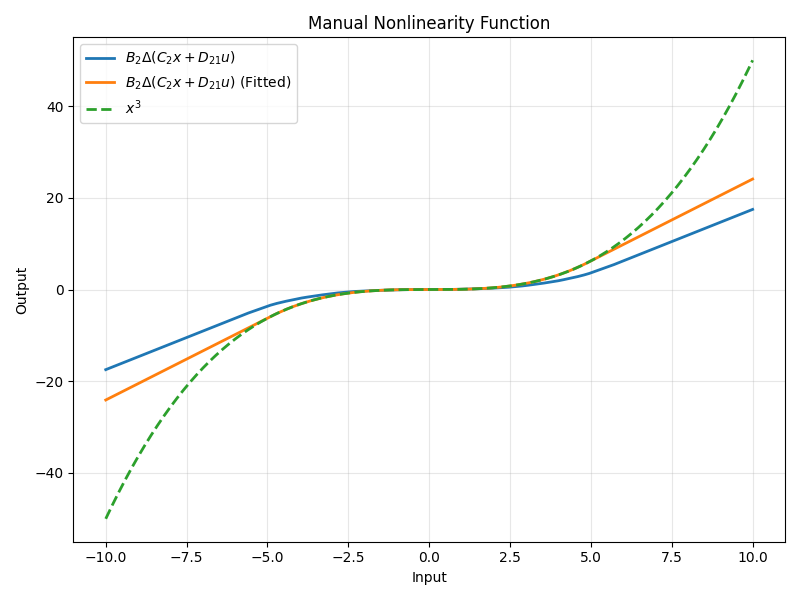

In [320]:
TS      = 0.05  # sample time [s]

# Plot the nonlinearity function
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(xs, y_hats,  linewidth=2, markersize=6, label=r'$B_2 \Delta(C_2 x + D_{21} u)$')
ax.plot(xs, y_hats_fitted,  linewidth=2, markersize=6, label=r'$B_2 \Delta(C_2 x + D_{21} u)$ (Fitted)')

ax.plot(xs, TS*xs**3, '--', linewidth=2, label=r'$x^3$')
ax.set_xlabel('Input')
ax.set_ylabel('Output')
ax.set_title('Manual Nonlinearity Function')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [287]:
Y = 1/(s**2 * C @ P @ C.T)
y_bound = 1/np.sqrt(Y)
print(f"Y: {Y}, y_bound: {y_bound}")
normalizer.inverse_transform_outputs(y_bound)

Y: [[0.13319749]], y_bound: [[2.74000898]]


array([[[0.43241506]]])

In [10]:
import cvxpy as cp

In [11]:
Y = cp.Variable((ne,ne))
ctr = [-C.T @ Y @ C + np.linalg.inv(P) /s**2 >> 0]
obj = cp.Maximize(cp.trace(Y))
prob = cp.Problem(obj, ctr)
prob.solve(solver=cp.MOSEK, verbose=False)
print(f'Problem status: {prob.status}')
print(f'Minimal output reachable set given by E(Y) with Y: {Y.value}')
y_bound = 1/np.sqrt(Y.value)
print(f"Y: {Y}, y_bound: {y_bound}")
normalizer.inverse_transform_outputs(y_bound)

Problem status: optimal
Minimal output reachable set given by E(Y) with Y: [[0.00609184]]
Y: var1, y_bound: [[12.81225568]]


array([[[2.02196865]]])

In [12]:
L

array([[ 0.0028204 , -0.00418405],
       [-0.00156652, -0.00150384],
       [-0.00042264, -0.00090204],
       [ 0.00224957,  0.00186407],
       [-0.00272095, -0.00251934],
       [-0.00126851, -0.00178169],
       [ 0.05681658,  0.02780417],
       [-0.00100212,  0.00334071],
       [ 0.00049639,  0.00134476],
       [ 0.00232279,  0.00157843]])

In [13]:

# calculate the output reachable set
P = cp.Variable((nx, nx), symmetric=True)
L = cp.Variable((nz, nx))
# L = np.zeros((nz, nx))  # fix L to zero for convexity
m = cp.Variable((nz, 1))
M = cp.diag(m)

eps = 1e-6
constraints = []

# stability constraints
F = cp.bmat(
    [
        [-(alpha**2) * P, np.zeros((nx, nd)), P @ C2.T + L.T, P @ A.T],
        [np.zeros((nd, nx)), -np.eye(nd), D21.T, B.T],
        [C2 @ P + L, D21, -2 * M, M @ B2.T],
        [A @ P, B, B2 @ M, -P],
    ]
)
nF = F.shape[0]
constraints.append(F << -eps * np.eye(nF))

# constraints for generalized sector condition
for i in range(nz):
    li = L[i, :].reshape((1, -1), order="C")
    locality_lmi = cp.bmat([[1/s**2, li], [li.T, P]])
    constraints.append(locality_lmi >> eps * np.eye(nx + 1))

# output reachable set constraints
Y_tilde = cp.Variable((ne,ne))
# constraints.append(cp.bmat([[P/s**2, (C @ P).T], [C @ P, Y_tilde]]) >> eps * np.eye(nx + ne))
constraints.append(cp.bmat([
    [Y_tilde, C @ P, D],
    [(C@P).T, P/s**2, np.zeros((nx,nd))],
    [D.T, np.zeros((nd,nx)), 1/delta.reshape((1,1))**2]
]) >> eps * np.eye(nx+ne+nd))

objective = cp.Minimize(cp.trace(Y_tilde))
problem = cp.Problem(objective, constraints )
problem.solve(solver=cp.MOSEK, verbose=True, accept_unknown=True)
print(f'Problem status: {problem.status}')
Y = 1/Y_tilde.value
print(f'Minimal output reachable set given by E(Y) with Y: {1/Y_tilde.value}')

(CVXPY) Apr 21 11:20:57 PM: Your problem has 35 variables, 331 constraints, and 0 parameters.
(CVXPY) Apr 21 11:20:57 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 21 11:20:57 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 21 11:20:57 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 21 11:20:57 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 21 11:20:57 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Apr 21 11:20:57 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> MOSEK
(CVXPY) Apr 21 11:20:57 PM: Applying reduction Dcp2Cone
(CVXPY) Apr 21 11:20:57 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 21 11:20:57 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 21 11:20:57 PM: Applying reduction MOSEK
(CVXPY) Apr 21 11:20:57 PM: Finished problem compilation (too

                                     CVXPY                                     
                                     v1.7.3                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------




(CVXPY) Apr 21 11:20:57 PM: 10  2.1e-04  6.9e-05  1.9e-06  1.28e-01   4.037563582e-03   4.170709395e-03   6.9e-05  0.06  
(CVXPY) Apr 21 11:20:57 PM: 11  6.7e-05  2.2e-05  1.3e-06  -6.46e-01  8.743845292e-03   8.522644111e-03   2.2e-05  0.06  
(CVXPY) Apr 21 11:20:57 PM: 12  1.7e-05  5.7e-06  2.6e-07  8.52e-02   1.953642133e-02   1.930933199e-02   5.7e-06  0.07  
(CVXPY) Apr 21 11:20:57 PM: 13  3.7e-06  1.2e-06  8.4e-08  -2.49e-01  4.077379015e-02   4.005119935e-02   1.2e-06  0.07  
(CVXPY) Apr 21 11:20:57 PM: 14  9.4e-07  3.1e-07  2.8e-08  -1.66e-01  7.680795808e-02   7.542866729e-02   3.1e-07  0.07  
(CVXPY) Apr 21 11:20:57 PM: 15  3.4e-07  1.1e-07  1.4e-08  -3.07e-01  1.176910484e-01   1.150092004e-01   1.1e-07  0.08  
(CVXPY) Apr 21 11:20:57 PM: 16  1.2e-07  4.1e-08  5.6e-09  -8.72e-02  2.100900413e-01   2.067721115e-01   4.1e-08  0.08  
(CVXPY) Apr 21 11:20:57 PM: 17  4.5e-08  1.5e-08  2.8e-09  -3.87e-01  3.488343157e-01   3.427281305e-01   1.5e-08  0.08  
(CVXPY) Apr 21 11:20:57 

-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Problem status: optimal
Minimal output reachable set given by E(Y) with Y: [[0.97491666]]


In [14]:
y_bound_n = 1/np.sqrt(Y)
print(f"Y: {Y}, y_bound: {y_bound_n}")
y_bound = normalizer.inverse_transform_outputs(y_bound_n)
print(f'Output of model is guranteed to be in the range [-{y_bound.squeeze():.4f}, {y_bound.squeeze():.4f}] mV')

Y: [[0.97491666]], y_bound: [[1.01278265]]
Output of model is guranteed to be in the range [-0.1598, 0.1598] mV


In [43]:
np.linalg.norm(L.value)

0.10204843163362688

In [7]:
# from https://github.com/MaartenSchoukens/nonlinear_benchmarks/blob/master/submission_examples/silverbox.py

import nonlinear_benchmarks

# Load data: 
# Keep this part fixed, though you can split the train set further in a train and validation set. 
# Do not use the test set to make any decision about the model (parameters, hyperparameters, structure, ...)
train, test = nonlinear_benchmarks.Silverbox()
test_multisine, test_arrow_full, test_arrow_no_extrapolation = test
n = test_multisine.state_initialization_window_length

In [8]:
import matplotlib.pyplot as plt
%matplotlib widget

In [9]:

u = test_multisine.u[n:]  # (N, nd)
y = test_multisine.y[n:]  # (N, ne)

u = u.reshape(-1, 1)

N, nd = u.shape

# Convert to torch tensors with batch dimension
u_torch = torch.tensor(u, dtype=torch.float32).unsqueeze(0)  # (1, N, nd)

# Normalize inputs if normalizer exists
if normalizer is not None:
    u_torch = normalizer.transform_inputs(u_torch)
    
# Run model (x0=None will use random initialization)
with torch.no_grad():
    y_pred_torch = model(u_torch, x0=None)  # (1, N, ne)
    
# Denormalize outputs if normalizer exists
if normalizer is not None:
    y_pred_torch = normalizer.inverse_transform_outputs(y_pred_torch)
    
# Convert back to numpy and remove batch dimension
y_pred = y_pred_torch.cpu().numpy().squeeze()  # (N,) or (N, ne)


    

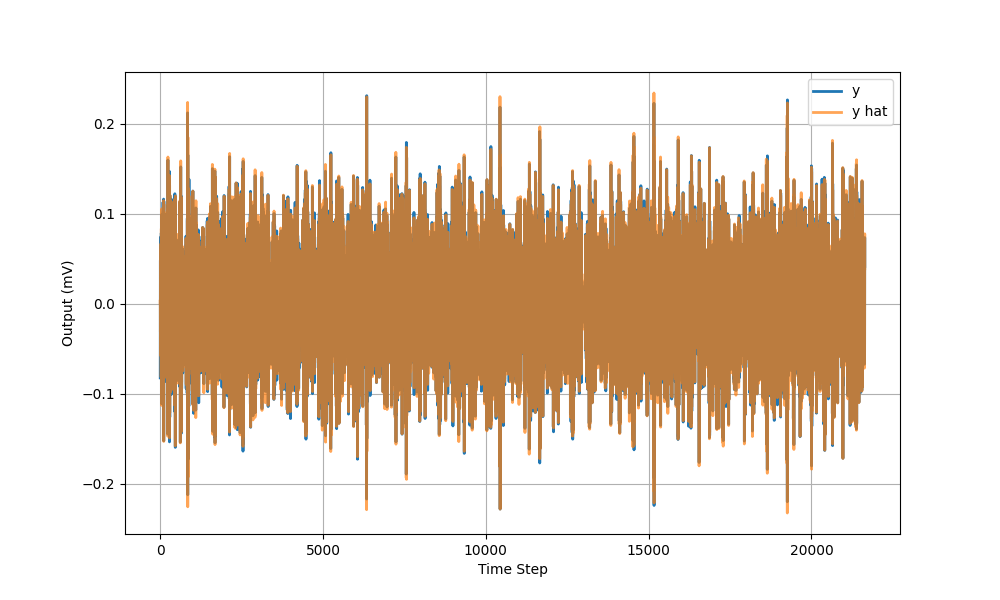

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(y, label="y", linewidth=2)
plt.plot(y_pred, label="y hat", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Output (mV)")
plt.legend()
plt.grid()
plt.show()  



In [10]:
y_hat, (x, w) = model(u_torch, x0=None, return_state=True)  # (1, N, ne)

In [127]:
P

array([[  8212.00882837,    879.38408448,  -3590.40388779,
          -157.73001877,   5008.35764961,   2093.73008733,
         -4350.30098064,  -6171.73882055,    213.13446985,
          7769.77966935],
       [   879.38408448,   6767.93830145,   2906.48745633,
         -7511.55149302,  -2257.78987767,  -1645.2208177 ,
          2529.8808001 ,  -3898.39064692,   8112.12462498,
          5456.15380279],
       [ -3590.40388779,   2906.48745633,  16896.85008696,
          2887.7992072 , -13005.64735656,   -691.44845473,
         -1103.95689944,  -4682.9232929 ,  10466.36599261,
         -9854.43685109],
       [  -157.73001877,  -7511.55149302,   2887.7992072 ,
         13194.27674537,  -2669.43637148,   4665.48284176,
         -8388.26569549,  -2838.56124522,  -7495.64901891,
         -7166.24361547],
       [  5008.35764961,  -2257.78987767, -13005.64735656,
         -2669.43637148,  12657.64399683,   -935.77541726,
          2795.1524678 ,   5498.85148903,  -7005.140575  ,
          7

In [132]:
L = L.value
P = P.value

In [133]:
print(f'Norm of P: {np.linalg.norm(P)}')
print(f'Norm of P^(-1)/s^2: {np.linalg.norm(np.linalg.inv(P)/s**2)}')
print(f'Norm of L: {np.linalg.norm(L)}')

print(f'Norm of A: {np.linalg.norm(A)}')
print(f'Norm of B: {np.linalg.norm(B)}')
print(f'Norm of B2: {np.linalg.norm(B2)}')

print(f'Norm of C: {np.linalg.norm(C)}')
print(f'Norm of D: {np.linalg.norm(D)}')
print(f'Norm of D12: {np.linalg.norm(D12)}')

print(f'Norm of C2: {np.linalg.norm(C2)}')
print(f'Norm of D21: {np.linalg.norm(D21)}')



Norm of P: 69651.91927575783
Norm of P^(-1)/s^2: 0.016281890115075127
Norm of L: 0.22178171893642545
Norm of A: 1.7746792950042696
Norm of B: 0.24608408433003667
Norm of B2: 0.10181813243818312
Norm of C: 1.3062178891080531
Norm of D: 0.015077127318881502
Norm of D12: 2.3644182789127153e-86
Norm of C2: 0.04318177251075299
Norm of D21: 0.011794654832819227


[[0.]]
[[0.06569237]]
[[-0.15190696]]
[[-0.45370574]]
[[-0.58334276]]
[[-0.51922404]]
[[-0.04218027]]
[[0.76079704]]
[[1.06379503]]
[[0.53992888]]
max a: 0.0000


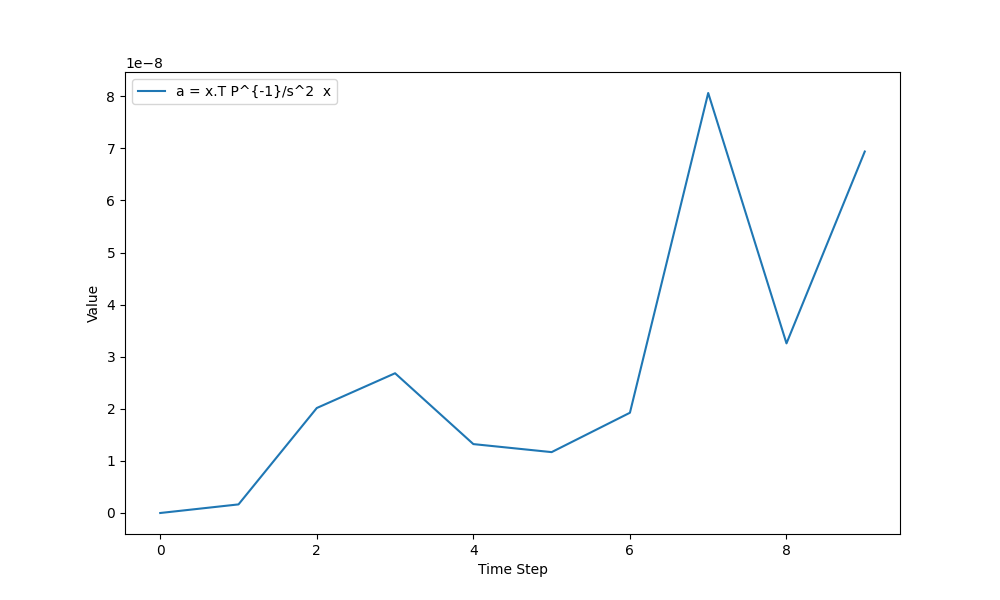

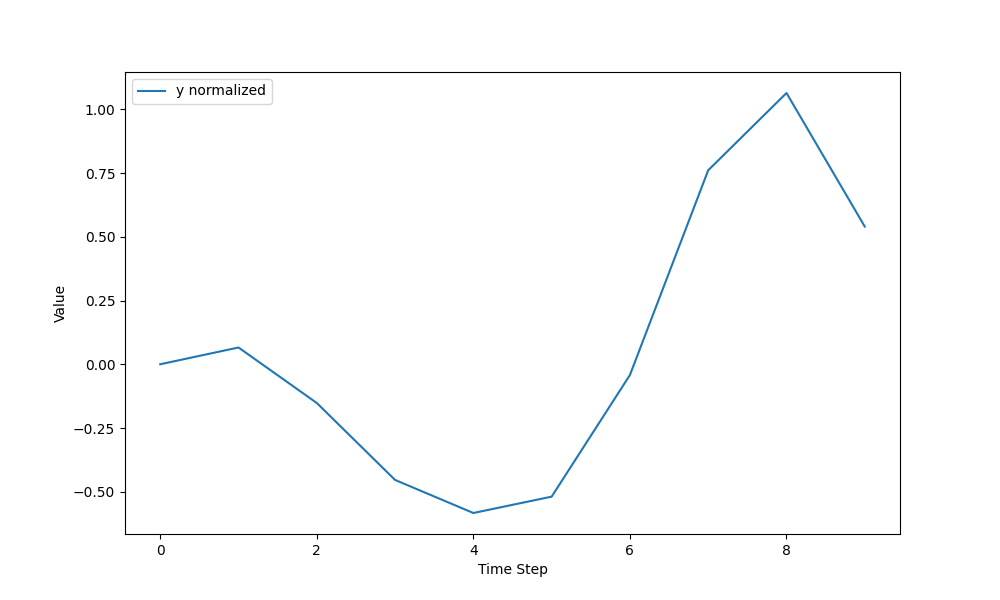

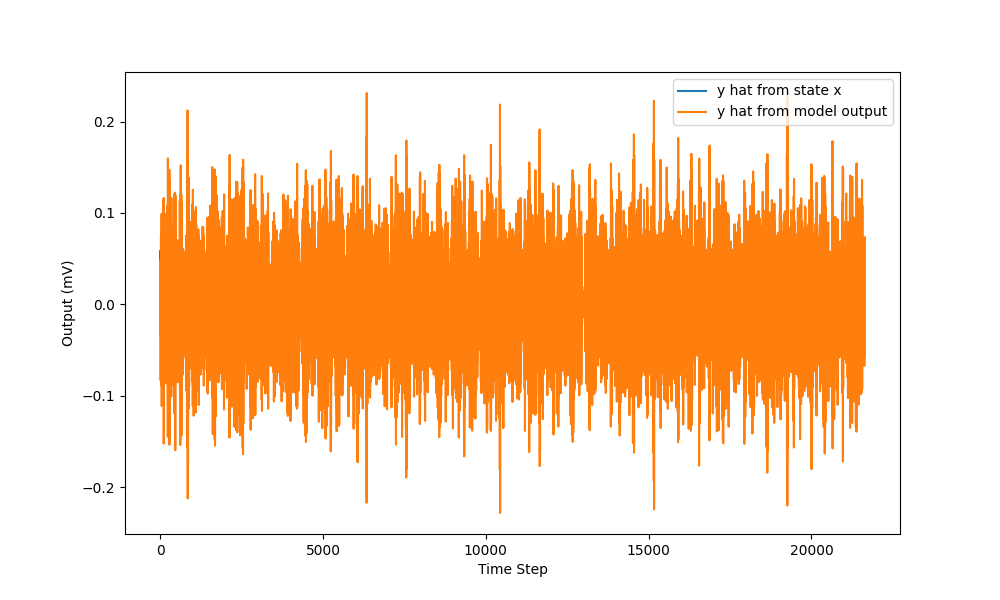

In [22]:
a_list = []
b_list = []
y_hat2 = []
for x_i in x[0,:10,:,:]:
    
    x_i = x_i.cpu().detach().numpy()
    print(C @ x_i)
    # print(x_i.T @ P.value @ x_i)
    a_list.append(x_i.T @ np.linalg.inv(P)/s**2 @ x_i)
    # b_list.append(x_i.T @ C.T @ Y @ C @ x_i)
    y_hat2.append(C @ x_i)

a = np.array(a_list).squeeze()
# b = np.array(b_list).squeeze()
y_hat2 = np.array(y_hat2).squeeze()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(a, label="a = x.T P^{-1}/s^2  x")
# ax.plot(b, label="b = x.T @ C.T @ Y @ C @ x")
ax.set_xlabel("Time Step")
ax.set_ylabel("Value")
ax.legend()
print(f'max a: {np.max(a):.4f}')
# print(f'max b: {np.max(b):.4f}')

# all(b <= a)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(y_hat2.squeeze(), label="y normalized")
ax.set_xlabel("Time Step")
ax.set_ylabel("Value")
ax.legend()


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(normalizer.inverse_transform_outputs(y_hat2).squeeze(), label="y hat from state x")
ax.plot(y.squeeze(), label="y hat from model output")
ax.set_xlabel("Time Step")
ax.set_ylabel("Output (mV)")
ax.legend() 

In [ ]:
normalizer.inverse_transform_outputs(y_hat2).shape

array([[ 8.62079790e-02,  5.22716324e-03, -3.24556755e-07,
        -1.94034759e-04,  1.16467827e-04,  1.81512779e-03,
        -2.47031568e-06,  2.68622355e-04, -1.73363719e-05,
        -4.32106715e-07],
       [ 5.22716324e-03,  3.16945553e-04, -1.96792821e-08,
        -1.17651681e-05,  7.06194889e-06,  1.10059061e-04,
        -1.49785942e-07,  1.62877371e-05, -1.05117933e-06,
        -2.62005021e-08],
       [-3.24556755e-07, -1.96792821e-08,  1.22189487e-12,
         7.30504214e-10, -4.38479365e-10, -6.83361322e-09,
         9.30027188e-12, -1.01131242e-09,  6.52681653e-11,
         1.62680015e-12],
       [-1.94034759e-04, -1.17651681e-05,  7.30504214e-10,
         4.36728575e-07, -2.62142866e-07, -4.08544415e-06,
         5.56012465e-09, -6.04608467e-07,  3.90202716e-08,
         9.72574968e-10],
       [ 1.16467827e-04,  7.06194889e-06, -4.38479365e-10,
        -2.62142866e-07,  1.57349178e-07,  2.45225547e-06,
        -3.33742076e-09,  3.62911441e-07, -2.34216088e-08,
        -5.

In [73]:
C

array([[ 2.91455412e+02,  1.76722043e+01, -1.09727457e-03,
        -6.56000539e-01,  3.93759125e-01,  6.13665722e+00,
        -8.35174288e-03,  9.08169290e-01, -5.86115053e-02,
        -1.46088381e-03]])